In [1]:
import numpy as np
from ase.io import read
from ase.visualize import view
from ase.db import connect
import sys
import pandas as pd
import matplotlib.pyplot as plt
import copy

import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.model_selection  import train_test_split
from scipy.optimize import least_squares, minimize, basinhopping

# from Helper_SurfEP_DirectFit_Dev import exportHostModel

#sys.path.append("/Users/Matt/pythonScripts/montemoregroup/src/montegroup/")
sys.path.append("/Users/hajar/Downloads/montemoregroup1/src/montegroup")
# from surfEP import surfEP
from ghit import GHIT
from coordsFunctions import snapCoords,findNeighborIndices

#pureElementDataFrame1 = pd.read_csv("/Users/Matt/Dropbox/Data/CuratedData/PureElementData.csv",index_col=0,skiprows=1)
#pureElementDataFrame2 = pd.read_csv("/Users/Matt/Dropbox/Data/CuratedData/MathematicaElementData.csv",index_col=0,skiprows=1)
#pureElementDataFrame = pd.concat([pureElementDataFrame1, pureElementDataFrame2],axis=1,sort=True)

# pureElementDataFrame1 = pd.read_csv("/Users/Matt/Dropbox/Data/CuratedData/PureElementData.csv",index_col=0,skiprows=1)
# pureElementDataFrame2 = pd.read_csv("/Users/Matt/Dropbox/Data/CuratedData/MathematicaElementData.csv",index_col=0,skiprows=1)
# pureElementDataFrame = pd.concat([pureElementDataFrame1, pureElementDataFrame2],axis=1,sort=True)

In [2]:
import importlib
import gnn_framework
importlib.reload(gnn_framework)

from gnn_framework import GNNModel, GraphSample


In [4]:
import sys
print(sys.executable)

/opt/anaconda3/envs/gcnn_safe_cpu/bin/python


In [5]:
import sys
!{sys.executable} -m pip install mace-torch

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 51.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 55.1 MB/s  0:00:00
  Created wheel for python-hostlist: filename=python_hostlist-2.3.0-py3-none-any.whl size=39523 sha256=6134fe29d93b29339316c44fad1703a4db14d27784d65a59f473d0e9fe1f9d68
  Stored in directory: /Users/hajar/Library/Caches/pip/wheels/88/72/73/002774455543bbe8fd7f53889f0076dc831c4e8f8bcdc56ffe
Successfully built python-hostlist
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16/16 [mace-torch]6 [e3nn]ipy]ics]


In [6]:
from mace.calculators import mace_mp

/opt/anaconda3/envs/gcnn_safe_cpu/lib/python3.10/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


In [7]:
def setup_mace_calculator(model="medium", device=None):
    """
    Set up the MACE-MP calculator.
    """
    if device is None:
        device = "cpu"
    
    print(f"Setting up MACE-MP calculator with model='{model}' on device='{device}'")
    
    # Initialize MACE-MP calculator
    calc = mace_mp(model=model, device=device)
    
    return calc

# Import and process data


In [3]:

### All input for data section should go here

### databases that already know the host binding atoms
databaseDir1 = '/Users/hajar/Downloads/Databases_PW91/'

databaseNames1 = ['hAdsProcessed.db','FProcessed.db','KProcessed.db',
               'nhxProcessed.db','nhxProcessed.db',
               'shxProcessed.db','shxProcessed.db',
               'chxProcessed.db','chxProcessed.db', 'chxProcessed.db','chxProcessed.db',
               'oxAdsProcessed.db','oxAdsProcessed.db','oxAdsProcessed.db','coProcessed.db'
                ]

databaseList1 = [connect(databaseDir1+databaseName) for databaseName in databaseNames1]

importGuestList1 = ['H','F','K',
                   'N','NH2',
                   'S','SH',
                   'C','Methyl', 'Methylene','Methylidyne', 
                   'O','Hydroxyl','Methoxy','CO'
                  ]

### databases that don't know the host binding atoms

#databaseDir2 = '/Users/Matt/Dropbox/Data/Databases_PW91/'

databaseDir2 = '/Users/hajar/Downloads/Databases_PW91/'
databaseNames2 = ['DissFinal.db','DissFinal.db','DissFinal.db','DissFinal.db',
                  'DissFinal.db','DissFinal.db','DissFinal.db','MoreMethylTop_Processed.db','MoreOH_Processed.db']
databaseList2 = [connect(databaseDir2+databaseName) for databaseName in databaseNames2]
importGuestList2 = ['CH4TS','CH3TS','CH2TS','CHTS',
                    'OHTS','H2OTS','COTS', 'Methyl','Hydroxyl']
gasPhaseEnList2 = [-24.091421,-18.176726,-12.058483,-6.102109,-7.579404,-14.26184735,-14.82331288,None,None]

bareSurfNewDB = connect(databaseDir2+'MSRNew12.db') 
bareSurfNew2DB = connect(databaseDir2+'bareSurfNew.db')

Notes on next cell:
- This assumes guest is always the first few atoms. Should fix this eventually.
    - Specifically, this is important for figuring out which atoms are host_binding_atoms. row.data.get('atoms_adsorbed_to') gives indices that apply to the bare surface.
- Relatedly, should fix this so it works no matter what order indices are in.
- The way we get host_binding_atoms is a bit dirty for some cases. In long run, will probably want to improve this.

In [4]:
### Get adsorption energy, binding site, binding elements, etc. Put in datafram (df)

d = []
atomsList = []

for database,inputGuest in zip(databaseList1,importGuestList1):
    for row in database.select():
#         print(row.get('guest_name'))
        if 'NiPt' in row.get('directory') or 'Sandwich' in row.get('directory') or 'HydrogenTi3inOs' in row.get('directory') or 'NH2ReonPt' in row.get('directory') or 'Step' in row.get('directory'):
            print(row.get('directory')+' skipped')
            continue
        if row.get('guest_name') != inputGuest:
            continue
        if 'Sn' in row.get('symbols') or 'Zn' in row.get('symbols'):
            continue
        print(row.get('directory'))
        print(row.get('guest_name'))
        atoms = row.toatoms()
        atoms.set_pbc(True)
        atomsList.append(atoms)
        symbols = np.array(atoms.get_chemical_symbols())
#         if symbols[0] != inputGuest: print('WARNING: Code probably went wrong because '+'guestAtom'+' is not first atom.')
        ghit = GHIT(row.toatoms())
        ghit.find_guest_atoms(guest_elements=['C','O','H','N','F','S','K'])
        print(ghit)
        print(row)
        try:
            host_binding_atoms_bare = row.data.get('atoms_adsorbed_to')
            ### TODO: Fix next line. It will almost certainly cause problems at some point. Should probably just detect host binding atoms in all cases.
            host_binding_atoms_adsorbed = np.array(host_binding_atoms_bare) + len(ghit.get_guest_atoms())
        except (ValueError, AttributeError):
            ghit.find_host_binding_atoms()
            host_binding_atoms_adsorbed = ghit.get_host_binding_atoms()[0]
        

        print(ghit.get_guest_atoms())
#         ghit.host_binding_atoms()
#         host_binding_atoms = ghit.get_host_binding_atoms()[0]
#         print(host_binding_atoms)
        host_binding_elements = symbols[list(host_binding_atoms_adsorbed)]
#         print(symbols[row.data.get('atoms_adsorbed_to')+1])
        #print(row.__dict__)
        #host_binding_atoms_bare = np.array(host_binding_atoms_bare,dtype='int')
        d.append({'directory':row.get('directory')[40:],'adsorption_energy':row.get('adsorption_energy'),
                  'site_name':row.get('site_name'), 'host_name':row.get('host_name'),
                'guest_name':row.get('guest_name'),'host_binding_elements':host_binding_elements,
                 'host_binding_atoms_ads':host_binding_atoms_adsorbed})

for database,inputGuest,gasPhaseEn in zip(databaseList2,importGuestList2,gasPhaseEnList2):
    for row in database.select():
#         print(row.get('guest_name'), row.get('host_name'))
        if row.get('guest_name') != inputGuest:
            continue
        print(row.get('directory'))
        print(row.get('guest_name'))
        siteName = 'top' ### BIG ASSUMPTION!!!!! TODO: FIX THIS!!!!
        atoms = row.toatoms()
        atoms.set_pbc(True)
        atomsList.append(atoms)
        symbols = np.array(atoms.get_chemical_symbols())
        ghit = GHIT(row.toatoms())
        ghit.set_pbc(True)
#         ghit.wrap(center=ghit.positions[0])
        ghit.find_guest_atoms(guest_elements=['C','O','H','N','F','S','K'])
        print('all guest:',ghit.get_guest_atoms())
        ghit.find_guest_binding_atoms(distance_gap_tolerance=0.5,check_saturation=True)
        print('gba',ghit.get_guest_binding_atoms())
        ghit.set_binding_sites(['ontop' for at in ghit.get_guest_binding_atoms()])
        ghit.find_host_binding_atoms()
        print(ghit.get_binding_sites())
        select_hba = [0]
        host_binding_atoms_adsorbed = np.array([item for sublist in ghit.get_host_binding_atoms() for item in sublist])[select_hba]
        print(host_binding_atoms_adsorbed)
        host_binding_elements = symbols[list(host_binding_atoms_adsorbed)]
        

        if gasPhaseEn is None: 
            adsEn = row.get('adsorption_energy')
        else:
            try:
                bareSurfRow = bareSurfNewDB.get('guest_name=BareSurf,host_name='+row.get('host_name')) #
                adsEn = row.get('energy') - bareSurfRow.get('energy') - gasPhaseEn
            except KeyError:
                bareSurfRow = bareSurfNew2DB.get('host_name='+row.get('host_name')) #
                adsEn = row.get('energy') - bareSurfRow.get('energy') - gasPhaseEn               
        d.append({'directory':row.get('directory')[40:],'adsorption_energy':adsEn,
                  'site_name':siteName, 'host_name':row.get('host_name'),
                'guest_name':row.get('guest_name'),'host_binding_elements':host_binding_elements,
                 'host_binding_atoms_ads':host_binding_atoms_adsorbed,
                 'guest_binding_atoms':ghit.get_guest_binding_atoms(), 
                 })
        
df = pd.DataFrame(d)

/Users/Matt/Dropbox/Data/CUBackupData/VASPonShared/Done/OxAds//HydrogenAg/Bridge
H
GHIT(symbols='HAg36', pbc=True, cell=[[8.821528443, 0.0, 0.0], [4.410764221, 7.639667299, 0.0], [0.0, 0.0, 24.009156537]], guest_atoms=..., host_atoms=..., masses=..., momenta=..., tags=..., constraint=FixAtoms(indices=[19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]), calculator=SinglePointCalculator(...))
<AtomsRow: formula=Ag36H, keys=site_name,adsorption_energy,host_name,directory,guest_name>
[0]
/Users/Matt/Dropbox/Data/CUBackupData/VASPonShared/Done/OxAds//HydrogenAg/FHollow
H
GHIT(symbols='HAg36', pbc=True, cell=[[8.821528443, 0.0, 0.0], [4.410764221, 7.639667299, 0.0], [0.0, 0.0, 24.009156537]], guest_atoms=..., host_atoms=..., masses=..., momenta=..., tags=..., constraint=FixAtoms(indices=[19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]), calculator=SinglePointCalculator(...))
<AtomsRow: formula=Ag36H, keys=site_name,adsorption_energy,host_name,dir

/Users/hajar/Downloads/montemoregroup1/src/montegroup/ghit.py:22: FutureWarning: Please use atoms.calc
  calculator=args[0].get_calculator(),
/Users/hajar/Downloads/montemoregroup1/src/montegroup/ghit.py:115: FutureWarning: Please use len(self) or, if your atoms are distributed, self.get_global_number_of_atoms.
  range(self.get_number_of_atoms()), guest_atoms, assume_unique=True


/Users/Matt/Dropbox/Data/CUBackupData/VASPonShared/Done/OtherAds/SulfurCu/Bridge
S
GHIT(symbols='SCu36', pbc=True, cell=[[7.753118968, 0.0, 0.0], [3.876559484, 6.714397605, 0.0], [0.0, 0.0, 21.101314603]], guest_atoms=..., host_atoms=..., masses=..., momenta=..., tags=..., calculator=SinglePointCalculator(...))
<AtomsRow: formula=Cu36S, keys=site_name,adsorption_energy,host_name,directory,guest_name>
[0]
/Users/Matt/Dropbox/Data/CUBackupData/VASPonShared/Done/OtherAds/SulfurCu/FHollow
S
GHIT(symbols='SCu36', pbc=True, cell=[[7.753118968, 0.0, 0.0], [3.876559484, 6.714397605, 0.0], [0.0, 0.0, 21.101314603]], guest_atoms=..., host_atoms=..., masses=..., momenta=..., tags=..., calculator=SinglePointCalculator(...))
<AtomsRow: formula=Cu36S, keys=site_name,adsorption_energy,host_name,directory,guest_name>
[0]
/Users/Matt/Dropbox/Data/CUBackupData/VASPonShared/Done/OtherAds/SulfurCu/HHollow
S
GHIT(symbols='SCu36', pbc=True, cell=[[7.753118968, 0.0, 0.0], [3.876559484, 6.714397605, 0.0], [0.

/Users/hajar/Downloads/montemoregroup1/src/montegroup/ghit.py:22: FutureWarning: Please use atoms.calc
  calculator=args[0].get_calculator(),
/Users/hajar/Downloads/montemoregroup1/src/montegroup/ghit.py:115: FutureWarning: Please use len(self) or, if your atoms are distributed, self.get_global_number_of_atoms.
  range(self.get_number_of_atoms()), guest_atoms, assume_unique=True


['ontop' 'ontop']
[11]
/home/nwaokorie/Desktop/DFT/Calculations/PyMatGenStuff/CH3Dissociation/CH3DissNi
CH3TS
all guest: [0 1 2 3]
gba [0 2]
['ontop' 'ontop']
[11]
/home/nwaokorie/Desktop/DFT/Calculations/PyMatGenStuff/CH3Dissociation/CH3DissRu
CH3TS
all guest: [0 1 2 3]
gba [0 2]
['ontop' 'ontop']
[12]
/home/nwaokorie/Desktop/DFT/Calculations/PyMatGenStuff/CH3Dissociation/CH3DissRh
CH3TS
all guest: [0 1 2 3]
gba [0 2]
['ontop' 'ontop']
[10]
/home/nwaokorie/Desktop/DFT/Calculations/PyMatGenStuff/MSRProject/CH3Dissociation/CH3DissAg
CH3TS
all guest: [0 1 2 3]
gba [0 2]
['ontop' 'ontop']
[7]
/home/nwaokorie/Desktop/DFT/Calculations/PyMatGenStuff/MSRProject/CH3Dissociation/CH3DissAu
CH3TS
all guest: [0 1 2 3]
gba [0 2]
['ontop' 'ontop']
[7]
/home/nwaokorie/Desktop/DFT/Calculations/PyMatGenStuff/MSRProject/CH3Dissociation/CH3DissCu
CH3TS
all guest: [0 1 2 3]
gba [0 2]
['ontop' 'ontop']
[11]
/home/nwaokorie/Desktop/DFT/Calculations/PyMatGenStuff/MSRProject/CH3Dissociation/CH3DissIr
CH3TS
al

In [5]:
print(len(df),len(atomsList))
display(df[df['guest_name'].str.contains("OH")]) #[['formulas','error','adsorption_energy','pred_adsorption_energy']]
print(d[1478])

1776 1776


,directory,adsorption_energy,site_name,host_name,guest_name,host_binding_elements,host_binding_atoms_ads,guest_binding_atoms
1467,/PyMatGenStuff/MSRProject/OHDissociation/OHDissNi,-2.481004,top,Ni,OHTS,[Ni],[7],"[0, 1]"
1468,/PyMatGenStuff/MSRProject/OHDissociation/OHDissRu,-2.674866,top,Ru,OHTS,[Ru],[6],"[0, 1]"
1469,/PyMatGenStuff/MSRProject/OHDissociation/OHDissRh,-2.139037,top,Rh,OHTS,[Rh],[9],"[0, 1]"
1470,/PyMatGenStuff/MSRProject/OHDissociation/OHDissAg,-0.400234,top,Ag,OHTS,[Ag],[7],"[0, 1]"
1471,/PyMatGenStuff/MSRProject/OHDissociation/OHDissAu,-0.070451,top,Au,OHTS,[Au],[8],"[0, 1]"
1472,/PyMatGenStuff/MSRProject/OHDissociation/OHDissCu,-1.683246,top,Cu,OHTS,[Cu],[7],"[0, 1]"
1473,/PyMatGenStuff/MSRProject/OHDissociation/OHDissIr,-1.550183,top,Ir,OHTS,[Ir],[8],"[0, 1]"
1474,/PyMatGenStuff/MSRProject/OHDissociation/OHDissPd,-1.207190,top,Pd,OHTS,[Pd],[10],"[0, 1]"
1475,/PyMatGenStuff/MSRProject/OHDissociation/OHDissPt,-1.428230,top,Pt,OHTS,[Pt],[8],"[0, 1]"
1476,/PyMatGenStuff/MSRProject/OHDissociation/OHDis...,-1.892880,top,Ir_Ag,OHTS,[Ir],[8],"[0, 1]"


{'directory': '/PyMatGenStuff/MSRProject/OHDissociation/OHDissTi_Ag', 'adsorption_energy': -4.027679169999995, 'site_name': 'top', 'host_name': 'Ti_Ag', 'guest_name': 'OHTS', 'host_binding_elements': array(['Ti'], dtype='<U2'), 'host_binding_atoms_ads': array([8]), 'guest_binding_atoms': array([0, 1])}


Look at a calculation, to see if something went wrong

In [6]:
rowNum = 1485 #1473 #1478
#bareDB = connect('/Users/Matt/Dropbox/Data/Databases_PW91/bareSurfNew.db') #MoreBare.db, MSRNew12.db, bareSurfNew.db, bareSurfClean.db
bareDB = connect('/Users/hajar/Downloads/Databases_PW91/bareSurfNew.db')
display(df.iloc[rowNum])
adsAtomsTemp = atomsList[rowNum]

try: print('mag mom ads:', adsAtomsTemp.get_magnetic_moment())
except Exception: print('no mag mom ads')
# print('energy ads',adsAtomsTemp.get_potential_energy())
adsAtomsTemp.wrap(center = (0.3,0.3,0.8))
# view(adsAtomsTemp)

bareSurfRow = bareDB.get('host_name='+df.iloc[rowNum]['host_name']) #guest_name=BareSurf or None
try: print(bareSurfRow.get('directory')[-30:])
except KeyError: print('no dir')

try: print('mag mom bare:', bareDB.get_magnetic_moment())
except Exception: print('no mag mom bare')
# print('energy bare',bareAtomsTemp.get_potential_energy())
bareAtomsTemp = bareSurfRow.toatoms()
bareAtomsTemp.wrap(center = (0.3,0.3,0.8))
# view(bareAtomsTemp)

directory                 issRu_Cu
adsorption_energy        -1.914379
site_name                      top
host_name                    Ru_Cu
guest_name                    OHTS
host_binding_elements         [Ru]
host_binding_atoms_ads         [6]
guest_binding_atoms       [36, 37]
Name: 1485, dtype: object

no mag mom ads
ses_PW91/CH4Diss/BareSurfRu_Cu
no mag mom bare


Drop some bad data

In [7]:
# dropList = [1650,1639,1636,1634,1537,1536,1535,1534,1533,1496,1494,1464,1463,1633,1635, 1640, 847, 848, 1570, 1571, 1492, 1493]
dropList = [1629, 1550, 1691, 1692, 1551, 1593, 1552, 1592, 1591, 
            1594, 1595, 1629, 1693, 1696, 1697, 1698, 1708, 847, 848, 1554, 1628] 
dropList = list(np.sort(np.unique(dropList))[::-1])

df.iloc[dropList]

df.drop(dropList,inplace=True)
print(len(df))

for num in dropList:
    del atomsList[num]
    
len(atomsList), len(dropList)

df.reset_index(drop=True, inplace=True) 

### TODO: Also keep old index around, which makes it much easier to identify weird cases
### Change drop=False, and old index will be in a column called 'index', I think. Have to make sure this doesn't break anything below.

1756


In [8]:
df.loc[1492]

directory                 /PyMatGenStuff/MSRProject/H2ODissociation/H2OD...
adsorption_energy                                                  0.959284
site_name                                                               top
host_name                                                                Cu
guest_name                                                            H2OTS
host_binding_elements                                                  [Cu]
host_binding_atoms_ads                                                 [11]
guest_binding_atoms                                                  [0, 1]
Name: 1492, dtype: object

In [9]:

dfOrig = copy.deepcopy(df)
df = dfOrig.loc[(dfOrig['adsorption_energy']<2.5)&(dfOrig['adsorption_energy']>-20)]
print(len(df))

# Keep atomsList in sync with the filtered dataframe
atomsListOrig = copy.deepcopy(atomsList)
atomsList = [atomsListOrig[i] for i in df.index]
# Reset dataframe index to match atomsList ordering
df.reset_index(drop=True, inplace=True)


1750


In [9]:
## Make adjacency/connectivity matrix. This is an important input going forward.
## Want a very clear hand off. Deliniate exactly what we'll need going forward--what does the GCNN need?

## I think we also want guest binding elements and host binding elements as features for GCNN. 
## Other adsorbate atoms will be use elements as features, I guess. Other surface atoms will have another feature set.

## Info we have: 
## In df: host_binding_elements, host_binding_atoms_ads, guest_name (for now, no guest_binding_atoms)
## atoms object, in atomsList
## Want guest_binding_elements sometime too. Looks like will take a bit of work--check if in databases or not.
## Maybe just do from scratch from atoms object.


In [10]:
atomsList[0]

Atoms(symbols='HAg36', pbc=True, cell=[[8.821528443, 0.0, 0.0], [4.410764221, 7.639667299, 0.0], [0.0, 0.0, 24.009156537]], constraint=FixAtoms(indices=[19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]), calculator=SinglePointCalculator(...))

In [11]:
def make_edge_list(atoms, verbose=False):
    """
    Create an edge list suitable for a convolutional graph neural network.
    Edges are classified as:
    - 'SS': surface-surface (host-host connections)
    - 'AA': adsorbate-adsorbate (guest-guest connections)
    - 'SA_bond': surface-adsorbate bond (binding connections between host and guest)
    
    Uses GHIT to identify guest atoms and binding pairs.
    Uses ASE NeighborList with adaptive cutoffs for surface atoms based on second-nearest neighbors.
    
    Parameters:
    - verbose: If True, prints cutoffs per element and neighbor counts per atom.
    """
    from ase.neighborlist import NeighborList
    from ase.data import covalent_radii
    from collections import defaultdict
    import numpy as np
    
    # Initialize GHIT and find atoms
    ghit = GHIT(atoms)
    ghit.find_guest_atoms(guest_elements=['C', 'O', 'H', 'N', 'F', 'S', 'K'])
    guest_atoms = set(ghit.get_guest_atoms())
    host_atoms = set(range(len(atoms))) - guest_atoms
    
    # Find binding atoms for SA_bond
    ghit.find_guest_binding_atoms(distance_gap_tolerance=0.5, check_saturation=True)
    ghit.find_host_binding_atoms()
    
    guest_binding = ghit.get_guest_binding_atoms()
    host_binding_lists = ghit.get_host_binding_atoms()
    
    # Create SA_bond edges (undirected)
    sa_edges = []
    for gb, hb_list in zip(guest_binding, host_binding_lists):
        for hb in hb_list:
            sa_edges.append((min(gb, hb), max(gb, hb), 'SA_bond'))
    
    # Create cutoffs
    symbols = atoms.get_chemical_symbols()
    cutoffs = []
    host_indices = list(host_atoms)
    for i in range(len(atoms)):
        if i in host_atoms:
            # Adaptive cutoff based on second-nearest surface neighbor
            dists = atoms.get_distances(i, host_indices, mic=True)
            sorted_dists = sorted(dists)
            second_nn = sorted_dists[1]  # Second smallest distance (first is 0)
            cutoffs.append(1.05 * second_nn  * 0.5) # 0.5 for diameter to radius
        else:
            # Fixed cutoff for guest atoms
            cutoffs.append(covalent_radii[atoms[i].number] * 1.1 + 0.1)
    
    if verbose:
        # Print cutoffs per element for troubleshooting (approximate for guests)
        cutoff_dict = defaultdict(list)
        for i, cutoff in enumerate(cutoffs):
            element = symbols[i]
            cutoff_dict[element].append(cutoff)
        print("Neighbor cutoffs per element (surface: adaptive, guest: fixed):")
        for element in sorted(cutoff_dict.keys()):
            cuts = cutoff_dict[element]
            if len(cuts) == 1:
                print(f"  {element}: {cuts[0]:.3f} Å")
            else:
                print(f"  {element}: {min(cuts):.3f} - {max(cuts):.3f} Å")
    
    nl = NeighborList(cutoffs, self_interaction=False, bothways=True)
    nl.update(atoms)
    
    edges = []
    for i in range(len(atoms)):
        neighbors = nl.get_neighbors(i)[0]
        for j in neighbors:
            if i < j:  # Avoid duplicates
                if i in host_atoms and j in host_atoms:
                    edges.append((i, j, 'SS'))
                elif i in guest_atoms and j in guest_atoms:
                    edges.append((i, j, 'AA'))
    
    if verbose:
        print("Neighbor counts per atom:")
        for i in range(len(atoms)):
            count = len(nl.get_neighbors(i)[0])
            print(f"  Atom {i} ({symbols[i]}): {count} neighbors")
    
    # Combine all edges
    edges.extend(sa_edges)
    return edges

In [12]:
make_edge_list(atomsList[10],verbose=True)

Neighbor cutoffs per element (surface: adaptive, guest: fixed):
  Au: 1.507 - 1.534 Å
  H: 0.441 Å
  Ti: 1.446 - 1.474 Å
Neighbor counts per atom:
  Atom 0 (H): 1 neighbors
  Atom 1 (Au): 10 neighbors
  Atom 2 (Au): 9 neighbors
  Atom 3 (Au): 9 neighbors
  Atom 4 (Ti): 9 neighbors
  Atom 5 (Ti): 9 neighbors
  Atom 6 (Ti): 9 neighbors
  Atom 7 (Ti): 9 neighbors
  Atom 8 (Ti): 9 neighbors
  Atom 9 (Ti): 9 neighbors
  Atom 10 (Ti): 12 neighbors
  Atom 11 (Ti): 12 neighbors
  Atom 12 (Ti): 12 neighbors
  Atom 13 (Ti): 12 neighbors
  Atom 14 (Ti): 12 neighbors
  Atom 15 (Ti): 12 neighbors
  Atom 16 (Ti): 12 neighbors
  Atom 17 (Ti): 12 neighbors
  Atom 18 (Ti): 12 neighbors
  Atom 19 (Ti): 12 neighbors
  Atom 20 (Ti): 12 neighbors
  Atom 21 (Ti): 12 neighbors
  Atom 22 (Ti): 12 neighbors
  Atom 23 (Ti): 12 neighbors
  Atom 24 (Ti): 12 neighbors
  Atom 25 (Ti): 12 neighbors
  Atom 26 (Ti): 12 neighbors
  Atom 27 (Ti): 12 neighbors
  Atom 28 (Ti): 9 neighbors
  Atom 29 (Ti): 9 neighbors
  Ato

/Users/hajar/Downloads/montemoregroup1/src/montegroup/ghit.py:22: FutureWarning: Please use atoms.calc
  calculator=args[0].get_calculator(),
/Users/hajar/Downloads/montemoregroup1/src/montegroup/ghit.py:115: FutureWarning: Please use len(self) or, if your atoms are distributed, self.get_global_number_of_atoms.
  range(self.get_number_of_atoms()), guest_atoms, assume_unique=True


[(1, np.int64(6), 'SS'),
 (1, np.int64(8), 'SS'),
 (1, np.int64(14), 'SS'),
 (1, np.int64(4), 'SS'),
 (1, np.int64(5), 'SS'),
 (1, np.int64(7), 'SS'),
 (1, np.int64(9), 'SS'),
 (1, np.int64(10), 'SS'),
 (1, np.int64(15), 'SS'),
 (2, np.int64(4), 'SS'),
 (2, np.int64(5), 'SS'),
 (2, np.int64(6), 'SS'),
 (2, np.int64(7), 'SS'),
 (2, np.int64(8), 'SS'),
 (2, np.int64(9), 'SS'),
 (2, np.int64(11), 'SS'),
 (2, np.int64(12), 'SS'),
 (2, np.int64(13), 'SS'),
 (3, np.int64(5), 'SS'),
 (3, np.int64(6), 'SS'),
 (3, np.int64(16), 'SS'),
 (3, np.int64(17), 'SS'),
 (3, np.int64(18), 'SS'),
 (3, np.int64(8), 'SS'),
 (3, np.int64(9), 'SS'),
 (3, np.int64(4), 'SS'),
 (3, np.int64(7), 'SS'),
 (4, np.int64(5), 'SS'),
 (4, np.int64(7), 'SS'),
 (4, np.int64(10), 'SS'),
 (4, np.int64(12), 'SS'),
 (4, np.int64(18), 'SS'),
 (4, np.int64(8), 'SS'),
 (5, np.int64(6), 'SS'),
 (5, np.int64(10), 'SS'),
 (5, np.int64(11), 'SS'),
 (5, np.int64(17), 'SS'),
 (5, np.int64(9), 'SS'),
 (6, np.int64(8), 'SS'),
 (6, np.in

In [13]:
### Doing train-test split, but not fitting models yet
import torch
from gnn_framework import GraphSample, FeatureBuilder, TypeSpecificEncoder, MultiRelationGNNLayer, GNNModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Set device
#device = torch.device('mps' if torch.mps.is_available() else 'cpu')
device = torch.device("cpu")
print(f"Using device: {device}")

# User-defined range of samples
#sample_range = range(1000)  # First n datapoints
sample_range =range(len(atomsList))
graphs = []
targets = []

for example_idx in sample_range:
    atoms_example = atomsList[example_idx]
    target_energy = df.iloc[example_idx]['adsorption_energy']
    targets.append(target_energy)

    # Generate edge list
    edges = make_edge_list(atoms_example, verbose=False)

    # Classify node types
    symbols = atoms_example.get_chemical_symbols()
    ghit = GHIT(atoms_example)
    ghit.find_guest_atoms(guest_elements=['C', 'O', 'H', 'N', 'F', 'S', 'K'])
    guest_atoms = set(ghit.get_guest_atoms())
    host_atoms = set(range(len(atoms_example))) - guest_atoms

    ghit.find_guest_binding_atoms(distance_gap_tolerance=0.5, check_saturation=True)
    ghit.find_host_binding_atoms()
    guest_binding = set(ghit.get_guest_binding_atoms())
    host_binding = set()
    for hb_list in ghit.get_host_binding_atoms():
        host_binding.update(hb_list)

    node_types = []
    for i in range(len(atoms_example)):
        if i in host_atoms:
            if i in host_binding:
                node_types.append(1)  # surface binding
            else:
                node_types.append(0)  # surface non-binding
        else:
            if i in guest_binding:
                node_types.append(3)  # adsorbate binding
            else:
                node_types.append(2)  # adsorbate non-binding

    # Build features
    features = torch.tensor([atoms_example[i].number for i in range(len(atoms_example))], dtype=torch.float).unsqueeze(-1).to(device)

    # Create edge tensors
    edge_index = torch.tensor([[e[0], e[1]] for e in edges], dtype=torch.long).t().to(device)
    edge_types = []
    for e in edges:
        if e[2] == 'SS':
            edge_types.append(0)
        elif e[2] == 'AA':
            edge_types.append(1)
        elif e[2] == 'SA_bond':
            edge_types.append(2)
    edge_type = torch.tensor(edge_types, dtype=torch.long).to(device)

    # Create GraphSample
    graph = GraphSample(
        x=features,
        edge_index=edge_index,
        edge_type=edge_type,
        node_type=torch.tensor(node_types, dtype=torch.long).to(device),
        y=torch.tensor([target_energy], dtype=torch.float).to(device),
        atoms=atoms_example
    )
    graphs.append(graph)

print(f"Created {len(graphs)} graphs")

# Train-test split
train_graphs, test_graphs = train_test_split(graphs, test_size=0.2, random_state=42)
print(f"Train set: {len(train_graphs)} graphs, Test set: {len(test_graphs)} graphs")

# Evaluation function
def evaluate_model(model, graphs, targets):
    model.eval()
    preds = []
    actuals = []
    with torch.no_grad():
        for graph, target in zip(graphs, targets):
            pred = model(graph)
            preds.append(pred.item())
            actuals.append(target)
    preds = np.array(preds)
    actuals = np.array(actuals)
    mae = mean_absolute_error(actuals, preds)
    rmse = np.sqrt(mean_squared_error(actuals, preds))
    r2 = r2_score(actuals, preds)
    max_error = np.max(np.abs(actuals-preds))
    return mae, rmse, r2, max_error, preds, actuals

Using device: cpu
Created 1750 graphs
Train set: 1400 graphs, Test set: 350 graphs


In [25]:
run_hyperparameter_tuning = True ### A flag on whether to run this cell or not

if run_hyperparameter_tuning:
    


    import itertools

    # Hyperparameter grid
    #param_grid = {'feature_dim': [8, 16], 'hidden_dim': [4, 8], 'num_layers': [1, 2], 'lr': [0.001, 0.01]}
    param_grid = {'feature_dim': [32, 64], 'hidden_dim': [256, 512], 'num_layers': [2, 4], 'lr': [0.001, 0.01]}
    param_combinations = list(itertools.product(*param_grid.values()))
    param_names = list(param_grid.keys())

    # Initialize tracking variables
    best_val_mae = float('inf')
    best_params = None
    best_model_state = None

    # Tuning parameters
    tuning_epochs = 1

    # Split train_graphs into train and val for tuning
    from sklearn.model_selection import train_test_split
    train_graphs_tune, val_graphs = train_test_split(train_graphs, test_size=0.2, random_state=42)

    print("Starting hyperparameter tuning...")
    for combo in param_combinations:
        params = dict(zip(param_names, combo))
        print(f"Tuning with params: {params}")
        
        # Separate model and optimizer params
        model_params = {k: v for k, v in params.items() if k != 'lr'}
        
        # Initialize model
        model = GNNModel(**model_params, output_dim=1).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'])
        loss_fn = torch.nn.MSELoss()
        
        # Train for tuning_epochs
        for epoch in range(tuning_epochs):
            total_loss = 0
            for graph in train_graphs_tune:
                optimizer.zero_grad()
                pred = model(graph)
                loss = loss_fn(pred, graph.y)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
        
        # Evaluate on validation set
        val_mae, _, _, _, _, _ = evaluate_model(model, val_graphs, [targets[graphs.index(g)] for g in val_graphs])
        print(f"  Val MAE: {val_mae:.4f}")
        
        if val_mae < best_val_mae:
            best_val_mae = val_mae
            best_params = params
            best_model_state = model.state_dict()

    print(f"Best params: {best_params}, Best Val MAE: {best_val_mae:.4f}")

    # Retrain best model on train + val with more epochs
    best_model_params = {k: v for k, v in best_params.items() if k != 'lr'}
    best_model = GNNModel(**best_model_params, output_dim=1).to(device)
    best_model.load_state_dict(best_model_state)
    optimizer = torch.optim.Adam(best_model.parameters(), lr=best_params['lr'])
    loss_fn = torch.nn.MSELoss()

Starting hyperparameter tuning...
Tuning with params: {'feature_dim': 16, 'hidden_dim': 64, 'num_layers': 2, 'lr': 0.001}
  Val MAE: 1.1296
Tuning with params: {'feature_dim': 16, 'hidden_dim': 64, 'num_layers': 2, 'lr': 0.01}
  Val MAE: 1.1180
Tuning with params: {'feature_dim': 16, 'hidden_dim': 64, 'num_layers': 4, 'lr': 0.001}
  Val MAE: 1.0929
Tuning with params: {'feature_dim': 16, 'hidden_dim': 64, 'num_layers': 4, 'lr': 0.01}
  Val MAE: 1.0989
Tuning with params: {'feature_dim': 16, 'hidden_dim': 128, 'num_layers': 2, 'lr': 0.001}
  Val MAE: 1.0801
Tuning with params: {'feature_dim': 16, 'hidden_dim': 128, 'num_layers': 2, 'lr': 0.01}
  Val MAE: 1.0638
Tuning with params: {'feature_dim': 16, 'hidden_dim': 128, 'num_layers': 4, 'lr': 0.001}
  Val MAE: 1.0773
Tuning with params: {'feature_dim': 16, 'hidden_dim': 128, 'num_layers': 4, 'lr': 0.01}
  Val MAE: 1.0394
Tuning with params: {'feature_dim': 32, 'hidden_dim': 64, 'num_layers': 2, 'lr': 0.001}
  Val MAE: 1.1038
Tuning with 

Starting training...
Epoch 1, Avg Train Loss: 2.6502
Epoch 2, Avg Train Loss: 1.7541
Epoch 3, Avg Train Loss: 1.5072
Epoch 4, Avg Train Loss: 1.3785
Epoch 5, Avg Train Loss: 1.2923
Epoch 6, Avg Train Loss: 1.2040
Epoch 7, Avg Train Loss: 1.1543
Epoch 8, Avg Train Loss: 1.1028
Epoch 9, Avg Train Loss: 1.0289
Epoch 10, Avg Train Loss: 0.9669
Epoch 11, Avg Train Loss: 0.9104
Epoch 12, Avg Train Loss: 0.8266
Epoch 13, Avg Train Loss: 0.7581
Epoch 14, Avg Train Loss: 0.6983
Epoch 15, Avg Train Loss: 0.6480
Epoch 16, Avg Train Loss: 0.6112
Epoch 17, Avg Train Loss: 0.5765
Epoch 18, Avg Train Loss: 0.5827
Epoch 19, Avg Train Loss: 0.5485
Epoch 20, Avg Train Loss: 0.5378
Epoch 21, Avg Train Loss: 0.5037
Epoch 22, Avg Train Loss: 0.5196
Epoch 23, Avg Train Loss: 0.4939
Epoch 24, Avg Train Loss: 0.5197
Epoch 25, Avg Train Loss: 0.4920
Epoch 26, Avg Train Loss: 0.4571
Epoch 27, Avg Train Loss: 0.4672
Epoch 28, Avg Train Loss: 0.4410
Epoch 29, Avg Train Loss: 0.4624
Epoch 30, Avg Train Loss: 0.450

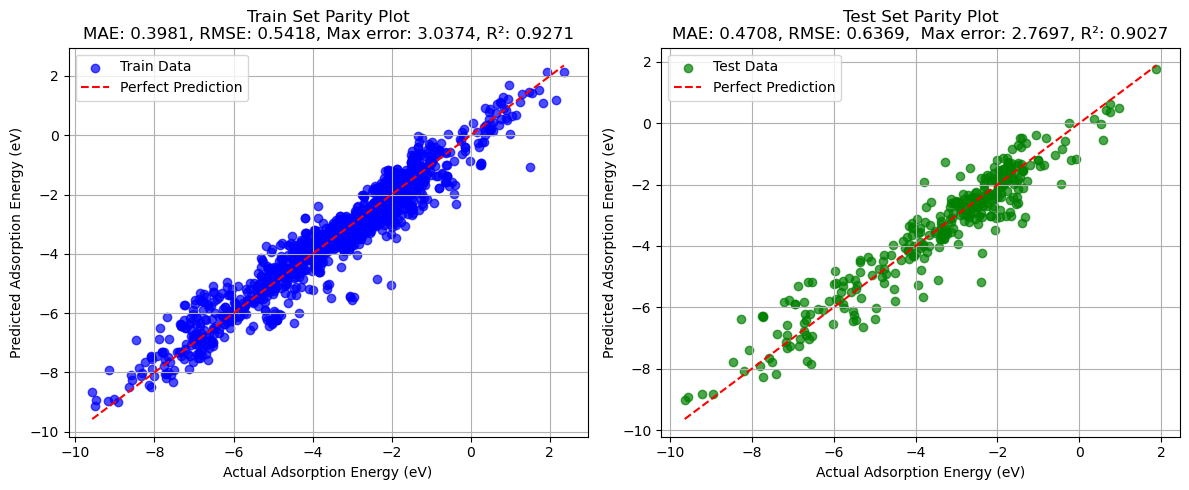


GNN framework example with train-test split and parity plots completed!


In [22]:
# Example: Run the GNN framework on the first n atoms objects with train-test split

# User-defined number of epochs
num_epochs = 100

# Best hyperparameters from tuning (update these after running the hyperparameter tuning cell above)
best_feature_dim = 16 #8
best_hidden_dim = 64 #8
best_num_layers = 2 #1
best_lr = 0.01 #0.01

# Initialize simplified model and move to device
model = GNNModel(feature_dim=best_feature_dim, hidden_dim=best_hidden_dim, output_dim=1, num_layers=best_num_layers).to(device)

# import time
# time.sleep(1) ### Added this to try to fix a weird issue with torch. Probalby not needed anymore.

# Quick training on the train samples
optimizer = torch.optim.Adam(model.parameters(), lr=best_lr)
loss_fn = torch.nn.MSELoss()

print('Starting training...')
for epoch in range(num_epochs):
    total_loss = 0
    for graph in train_graphs:
        optimizer.zero_grad()
        pred = model(graph)
        loss = loss_fn(pred, graph.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_graphs)
    print(f"Epoch {epoch+1}, Avg Train Loss: {avg_loss:.4f}")



# Get targets for train and test
train_targets = [targets[graphs.index(g)] for g in train_graphs]
test_targets = [targets[graphs.index(g)] for g in test_graphs]

# Evaluate on train set
train_mae, train_rmse, train_r2, train_max_error, train_preds, train_actuals = evaluate_model(model, train_graphs, train_targets)
print(f"\nTrain Set Metrics:")
print(f"MAE: {train_mae:.4f} eV")
print(f"RMSE: {train_rmse:.4f} eV")
print(f"R²: {train_r2:.4f}")
print(f"Max error: {train_max_error:.4f} eV")


# Evaluate on test set
test_mae, test_rmse, test_r2, test_max_error, test_preds, test_actuals = evaluate_model(model, test_graphs, test_targets)
print(f"\nTest Set Metrics:")
print(f"MAE: {test_mae:.4f} eV")
print(f"RMSE: {test_rmse:.4f} eV")
print(f"R²: {test_r2:.4f}")
print(f"Max error: {test_max_error:.4f} eV")


# Parity plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Train set parity plot
ax1.scatter(train_actuals, train_preds, alpha=0.7, color='blue', label='Train Data')
ax1.plot([min(train_actuals), max(train_actuals)], [min(train_actuals), max(train_actuals)], 'r--', label='Perfect Prediction')
ax1.set_xlabel('Actual Adsorption Energy (eV)')
ax1.set_ylabel('Predicted Adsorption Energy (eV)')
ax1.set_title(f'Train Set Parity Plot\nMAE: {train_mae:.4f}, RMSE: {train_rmse:.4f}, Max error: {train_max_error:.4f}, R²: {train_r2:.4f}')
ax1.legend()
ax1.grid(True)

# Test set parity plot
ax2.scatter(test_actuals, test_preds, alpha=0.7, color='green', label='Test Data')
ax2.plot([min(test_actuals), max(test_actuals)], [min(test_actuals), max(test_actuals)], 'r--', label='Perfect Prediction')
ax2.set_xlabel('Actual Adsorption Energy (eV)')
ax2.set_ylabel('Predicted Adsorption Energy (eV)')
ax2.set_title(f'Test Set Parity Plot\nMAE: {test_mae:.4f}, RMSE: {test_rmse:.4f},  Max error: {test_max_error:.4f}, R²: {test_r2:.4f}')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print("\nGNN framework example with train-test split and parity plots completed!")

In [23]:
df.iloc[sample_range]
# df.iloc[0:131]

,directory,adsorption_energy,site_name,host_name,guest_name,host_binding_elements,host_binding_atoms_ads,guest_binding_atoms
0,SPonShared/Done/OxAds//HydrogenAg/Bridge,-2.012176,bridge,Ag,H,"[Ag, Ag]","[1, 3]",NaN
1,SPonShared/Done/OxAds//HydrogenAg/FHollow,-2.143688,fcc_hollow,Ag,H,"[Ag, Ag, Ag]","[4, 3, 2]",NaN
2,SPonShared/Done/OxAds//HydrogenAg/HHollow,-2.136637,fcc_hollow,Ag,H,"[Ag, Ag, Ag]","[1, 3, 2]",NaN
3,SPonShared/Done/OxAds//HydrogenAg/Top,-1.561496,top,Ag,H,[Ag],[1],NaN
4,SPonShared/Done/OxAds//HydrogenAg3inTi/Top1_Co...,-1.916050,top,Ag3inTi,H,[Ag],[1],NaN
...,...,...,...,...,...,...,...,...
1745,lations/MorePW91Data/W_Hf_config1_OH_3,-4.768610,top,a84f7823f47112c3adab3f670a78c097,Hydroxyl,[W],[0],[36]
1746,lations/MorePW91Data/W_Os_config4_OH_3,-4.590906,top,b6a845c3a83d3bef8d206e61707c54f3,Hydroxyl,[W],[3],[36]
1747,lations/MorePW91Data/W_Pt_config4_OH_3,-4.266903,top,aa6482e8d290b5dc1dee69cab358986d,Hydroxyl,[W],[3],[36]
1748,lations/MorePW91Data/W_Re_config1_OH_3,-5.409650,top,3ac5970eb37526f3fb7c9ab96b8807c1,Hydroxyl,[W],[0],[36]


In [14]:
import torch
from gnn_framework import GraphSample, GNNModel
from sklearn.model_selection import train_test_split
import numpy as np
import itertools

# Set device
device = torch.device("cpu")  # change to "cuda" if GPU available
print(f"Using device: {device}")

# --- Hyperparameter tuning ---
run_hyperparameter_tuning = True
if run_hyperparameter_tuning:

    param_grid = {
        'feature_dim': [32, 64],
        'hidden_dim': [256, 512],
        'num_layers': [2, 4],
        'lr': [0.001, 0.01]
    }

    param_combinations = list(itertools.product(*param_grid.values()))
    param_names = list(param_grid.keys())

    best_val_mae = float('inf')
    best_params = None
    best_model_state = None

    # Early stopping settings
    patience = 5
    max_tuning_epochs = 50

    # Split training set into train + validation
    train_graphs_tune, val_graphs = train_test_split(
        train_graphs, test_size=0.2, random_state=42
    )

    print("Starting hyperparameter tuning...")
    for combo in param_combinations:
        params = dict(zip(param_names, combo))
        print(f"Tuning with params: {params}")

        model_params = {k: v for k, v in params.items() if k != 'lr'}

        model = GNNModel(**model_params, output_dim=1).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'])
        loss_fn = torch.nn.MSELoss()

        combo_best_val_mae = float('inf')
        combo_best_state = None
        counter = 0

        for epoch in range(max_tuning_epochs):

            # --- Training ---
            model.train()
            total_loss = 0

            for graph in train_graphs_tune:
                optimizer.zero_grad()
                pred = model(graph)
                loss = loss_fn(pred, graph.y)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()

            avg_train_loss = total_loss / len(train_graphs_tune)

            # --- Validation ---
            val_targets_norm = [g.y.item() for g in val_graphs]
            val_mae, _, _, _, _, _ = evaluate_model(model, val_graphs, val_targets_norm)

            # --- Early stopping ---
            if val_mae < combo_best_val_mae:
                combo_best_val_mae = val_mae
                combo_best_state = model.state_dict()
                counter = 0
            else:
                counter += 1
                if counter >= patience:
                    print(f"  Early stopping at epoch {epoch+1}")
                    model.load_state_dict(combo_best_state)
                    break

        print(f"  Best Val MAE for this combo: {combo_best_val_mae:.4f}")

        # Track overall best
        if combo_best_val_mae < best_val_mae:
            best_val_mae = combo_best_val_mae
            best_params = params
            best_model_state = combo_best_state

    print(f"\nBest params: {best_params}")
    print(f"Best Validation MAE: {best_val_mae:.4f}")


Using device: cpu
Starting hyperparameter tuning...
Tuning with params: {'feature_dim': 32, 'hidden_dim': 256, 'num_layers': 2, 'lr': 0.001}
  Best Val MAE for this combo: 0.4893
Tuning with params: {'feature_dim': 32, 'hidden_dim': 256, 'num_layers': 2, 'lr': 0.01}
  Early stopping at epoch 22
  Best Val MAE for this combo: 0.5531
Tuning with params: {'feature_dim': 32, 'hidden_dim': 256, 'num_layers': 4, 'lr': 0.001}
  Early stopping at epoch 37
  Best Val MAE for this combo: 0.5558
Tuning with params: {'feature_dim': 32, 'hidden_dim': 256, 'num_layers': 4, 'lr': 0.01}
  Early stopping at epoch 48
  Best Val MAE for this combo: 0.6211
Tuning with params: {'feature_dim': 32, 'hidden_dim': 512, 'num_layers': 2, 'lr': 0.001}
  Early stopping at epoch 40
  Best Val MAE for this combo: 0.5073
Tuning with params: {'feature_dim': 32, 'hidden_dim': 512, 'num_layers': 2, 'lr': 0.01}
  Early stopping at epoch 30
  Best Val MAE for this combo: 0.5346
Tuning with params: {'feature_dim': 32, 'hid


Starting final training (Max 400 epochs)...
Epoch 005 | Train Loss: 1.2955 | Val MAE: 1.0048
Epoch 010 | Train Loss: 1.0602 | Val MAE: 0.8194
Epoch 015 | Train Loss: 0.9034 | Val MAE: 0.7219
Epoch 020 | Train Loss: 0.6771 | Val MAE: 0.6350
Epoch 025 | Train Loss: 0.5455 | Val MAE: 0.5405
Epoch 030 | Train Loss: 0.4470 | Val MAE: 0.4937
Epoch 035 | Train Loss: 0.3981 | Val MAE: 0.4712
Epoch 040 | Train Loss: 0.3804 | Val MAE: 0.4801
Epoch 045 | Train Loss: 0.3579 | Val MAE: 0.4699
Epoch 050 | Train Loss: 0.3372 | Val MAE: 0.4128
Epoch 055 | Train Loss: 0.3303 | Val MAE: 0.4017
Epoch 060 | Train Loss: 0.3157 | Val MAE: 0.3945
Epoch 065 | Train Loss: 0.3045 | Val MAE: 0.3901
Epoch 070 | Train Loss: 0.3016 | Val MAE: 0.3853
Epoch 075 | Train Loss: 0.2945 | Val MAE: 0.3758
Epoch 080 | Train Loss: 0.2817 | Val MAE: 0.3753
Epoch 085 | Train Loss: 0.2808 | Val MAE: 0.3690
Epoch 090 | Train Loss: 0.2754 | Val MAE: 0.3751
Epoch 095 | Train Loss: 0.2734 | Val MAE: 0.3604
Epoch 100 | Train Loss: 

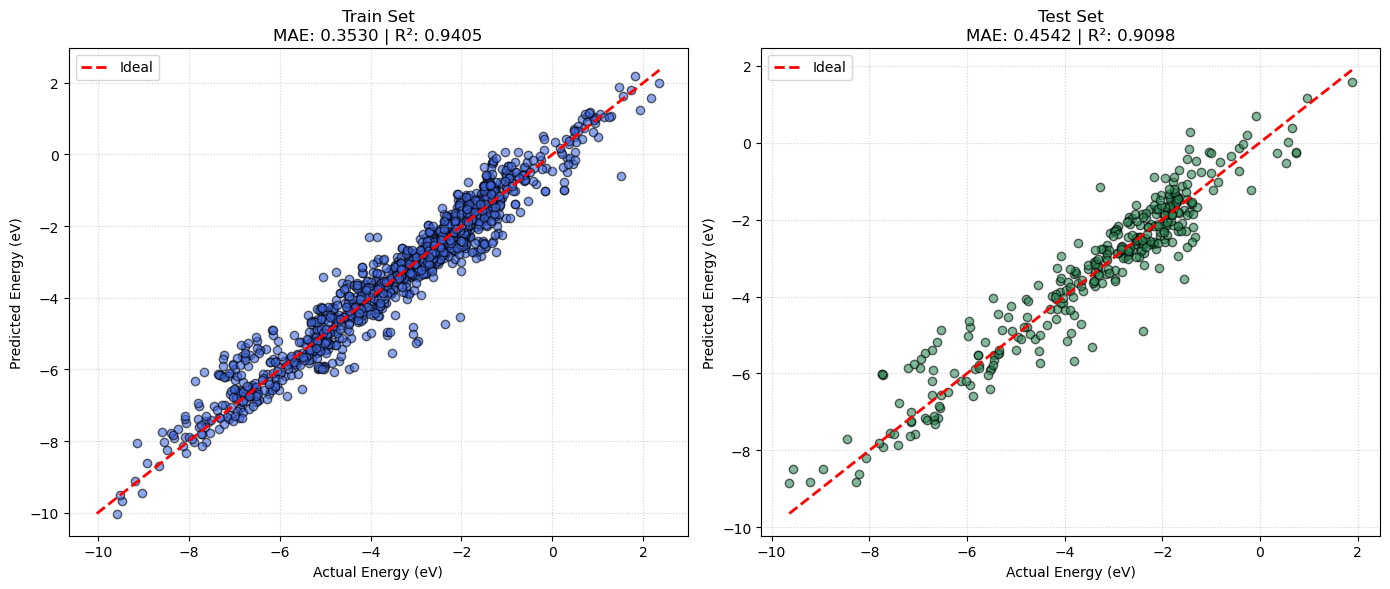


Training Complete. Final Test MAE: 0.4542 eV


In [29]:
import torch
import matplotlib.pyplot as plt

# --- 1. Configuration & Parameter Loading ---
#if 'best_params' in locals():
 #   best_feature_dim = best_params['feature_dim']
  #  best_hidden_dim = best_params['hidden_dim']
   # best_num_layers = best_params['num_layers']
    #best_lr = best_params['lr']
   # print(f"Using best params: {best_params}")
#else:
 #   best_feature_dim, best_hidden_dim, best_num_layers, best_lr = 16, 64, 2, 0.01
  #  print("Warning: best_params not found. Using manual defaults.")

best_feature_dim = 64 #8
best_hidden_dim = 256 #8
best_num_layers = 2 #1
best_lr = 0.001 #0.01

# --- 2. Initialize Model & Optimizer ---
model = GNNModel(
    feature_dim=best_feature_dim,
    hidden_dim=best_hidden_dim,
    output_dim=1,
    num_layers=best_num_layers
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=best_lr)
loss_fn = torch.nn.MSELoss()

# --- 3. Training with Early Stopping ---
num_epochs = 400
patience = 25
best_val_mae = float('inf')
best_state = None
counter = 0

print(f'\nStarting final training (Max {num_epochs} epochs)...')

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for graph in train_graphs:
        optimizer.zero_grad()
        pred = model(graph)
        loss = loss_fn(pred, graph.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_graphs)

    # --- Validation ---
    model.eval()
    val_targets = [g.y.item() for g in val_graphs]
    val_mae, _, _, _, _, _ = evaluate_model(model, val_graphs, val_targets)

    # --- Early Stopping ---
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        best_state = model.state_dict()
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Stopping early at epoch {epoch+1}. Restoring best weights.")
            model.load_state_dict(best_state)
            break

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:03d} | Train Loss: {avg_loss:.4f} | Val MAE: {val_mae:.4f}")

# --- 4. Final Evaluation ---
print("\n--- Final Evaluation ---")

train_targets = [g.y.item() for g in train_graphs]
test_targets = [g.y.item() for g in test_graphs]

train_metrics = evaluate_model(model, train_graphs, train_targets)
test_metrics = evaluate_model(model, test_graphs, test_targets)

train_mae, train_rmse, train_r2, train_max, train_preds, train_actuals = train_metrics
test_mae, test_rmse, test_r2, test_max, test_preds, test_actuals = test_metrics

# --- 5. Visualization ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

def plot_parity(ax, actual, pred, mae, r2, title, color):
    ax.scatter(actual, pred, alpha=0.6, color=color, edgecolors='k')
    lims = [min(min(actual), min(pred)), max(max(actual), max(pred))]
    ax.plot(lims, lims, 'r--', lw=2, label='Ideal')
    ax.set_xlabel('Actual Energy (eV)')
    ax.set_ylabel('Predicted Energy (eV)')
    ax.set_title(f'{title}\nMAE: {mae:.4f} | R²: {r2:.4f}')
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.6)

plot_parity(ax1, train_actuals, train_preds, train_mae, train_r2, "Train Set", "royalblue")
plot_parity(ax2, test_actuals, test_preds, test_mae, test_r2, "Test Set", "seagreen")

plt.tight_layout()
plt.show()

print(f"\nTraining Complete. Final Test MAE: {test_mae:.4f} eV")


In [30]:
import torch
from gnn_framework import GraphSample, GNNModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import itertools

# Set device
device = torch.device("cpu")  # change to "cuda" if GPU available
print(f"Using device: {device}")



# --- Hyperparameter tuning ---
run_hyperparameter_tuning = True
if run_hyperparameter_tuning:

    param_grid = {
        'feature_dim': [32, 64],
        'hidden_dim': [128, 256],
        'num_layers': [2, 4],
        'lr': [0.001, 0.01]
    }
    param_combinations = list(itertools.product(*param_grid.values()))
    param_names = list(param_grid.keys())

    best_val_mae = float('inf')
    best_params = None
    best_model_state = None

    # Early stopping & tuning settings
    patience = 5
    max_tuning_epochs = 10

    # Split train into train+val for tuning
    train_graphs_tune, val_graphs = train_test_split(train_graphs, test_size=0.2, random_state=42)

    print("Starting hyperparameter tuning...")
    for combo in param_combinations:
        params = dict(zip(param_names, combo))
        print(f"Tuning with params: {params}")

        # Separate model params and optimizer LR
        model_params = {k: v for k, v in params.items() if k != 'lr'}

        model = GNNModel(**model_params, output_dim=1).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'])
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=5
        )
        loss_fn = torch.nn.MSELoss()

        combo_best_val_mae = float('inf')
        combo_best_state = None
        counter = 0

        for epoch in range(max_tuning_epochs):
            # --- Training ---
            model.train()
            total_loss = 0
            for graph in train_graphs_tune:
                optimizer.zero_grad()
                pred = model(graph)
                loss = loss_fn(pred, graph.y)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
            avg_train_loss = total_loss / len(train_graphs_tune)

            # --- Validation ---
            val_targets_norm = [g.y.item() for g in val_graphs]
            val_mae, _, _, _, _, _ = evaluate_model(model, val_graphs, val_targets_norm)

            scheduler.step(val_mae)

            # --- Early stopping ---
            if val_mae < combo_best_val_mae:
                combo_best_val_mae = val_mae
                combo_best_state = model.state_dict()
                counter = 0
            else:
                counter += 1
                if counter >= patience:
                    print(f"  Early stopping at epoch {epoch+1}")
                    model.load_state_dict(combo_best_state)
                    break

        print(f"  Best Val MAE for this combo: {combo_best_val_mae:.4f}")

        # Track overall best
        if combo_best_val_mae < best_val_mae:
            best_val_mae = combo_best_val_mae
            best_params = params
            best_model_state = combo_best_state

    print(f"Best params: {best_params}, Best Val MAE: {best_val_mae:.4f}")



Using device: cpu
Starting hyperparameter tuning...
Tuning with params: {'feature_dim': 32, 'hidden_dim': 128, 'num_layers': 2, 'lr': 0.001}
  Best Val MAE for this combo: 0.7633
Tuning with params: {'feature_dim': 32, 'hidden_dim': 128, 'num_layers': 2, 'lr': 0.01}
  Best Val MAE for this combo: 0.7067
Tuning with params: {'feature_dim': 32, 'hidden_dim': 128, 'num_layers': 4, 'lr': 0.001}
  Best Val MAE for this combo: 0.7831
Tuning with params: {'feature_dim': 32, 'hidden_dim': 128, 'num_layers': 4, 'lr': 0.01}
  Best Val MAE for this combo: 0.7778
Tuning with params: {'feature_dim': 32, 'hidden_dim': 256, 'num_layers': 2, 'lr': 0.001}
  Best Val MAE for this combo: 0.7350
Tuning with params: {'feature_dim': 32, 'hidden_dim': 256, 'num_layers': 2, 'lr': 0.01}
  Best Val MAE for this combo: 0.6887
Tuning with params: {'feature_dim': 32, 'hidden_dim': 256, 'num_layers': 4, 'lr': 0.001}
  Best Val MAE for this combo: 0.7484
Tuning with params: {'feature_dim': 32, 'hidden_dim': 256, 'nu

Using best params: {'feature_dim': 64, 'hidden_dim': 256, 'num_layers': 2, 'lr': 0.01}

Starting final training (Max 200 epochs)...
Epoch 005 | Train Loss: 1.2518 | Val MAE: 0.8152
Epoch 010 | Train Loss: 0.7697 | Val MAE: 0.6043
Epoch 015 | Train Loss: 0.5976 | Val MAE: 0.5035
Epoch 020 | Train Loss: 0.5272 | Val MAE: 0.4862
Epoch 025 | Train Loss: 0.4778 | Val MAE: 0.4920
Epoch 030 | Train Loss: 0.4708 | Val MAE: 0.5011
Epoch 035 | Train Loss: 0.4279 | Val MAE: 0.4473
Epoch 040 | Train Loss: 0.3937 | Val MAE: 0.4374
Epoch 045 | Train Loss: 0.3159 | Val MAE: 0.4650
Epoch 050 | Train Loss: 0.2813 | Val MAE: 0.4075
Epoch 055 | Train Loss: 0.2731 | Val MAE: 0.3959
Epoch 060 | Train Loss: 0.2678 | Val MAE: 0.3908
Epoch 065 | Train Loss: 0.2633 | Val MAE: 0.3861
Epoch 070 | Train Loss: 0.2604 | Val MAE: 0.3813
Epoch 075 | Train Loss: 0.2562 | Val MAE: 0.3776
Epoch 080 | Train Loss: 0.2553 | Val MAE: 0.3725
Epoch 085 | Train Loss: 0.2536 | Val MAE: 0.3708
Epoch 090 | Train Loss: 0.2517 | Va

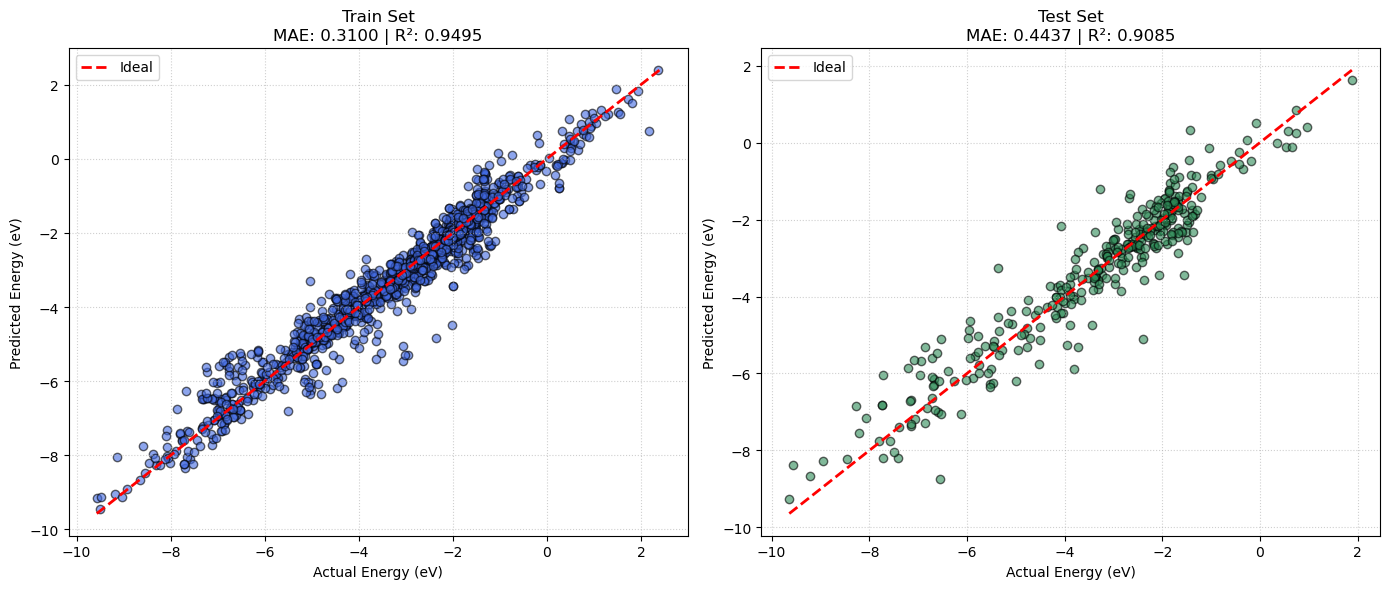


Training Complete. Final Test MAE: 0.4437 eV


In [32]:
import torch
import matplotlib.pyplot as plt

# --- 1. Configuration & Parameter Loading ---
# This pulls directly from your previous tuning cell results
if 'best_params' in locals():
    best_feature_dim = best_params['feature_dim']
    best_hidden_dim = best_params['hidden_dim']
    best_num_layers = best_params['num_layers']
    best_lr = best_params['lr']
    print(f"Using best params: {best_params}")
else:
    # Fallback defaults if tuning wasn't run
    best_feature_dim, best_hidden_dim, best_num_layers, best_lr = 16, 64, 2, 0.01
    print("Warning: best_params not found. Using manual defaults.")

# --- 2. Initialize Model & Tools ---
model = GNNModel(
    feature_dim=best_feature_dim, 
    hidden_dim=best_hidden_dim, 
    output_dim=1, 
    num_layers=best_num_layers
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=best_lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
loss_fn = torch.nn.MSELoss()

# --- 3. Training with Early Stopping ---
num_epochs = 200
patience = 25  # Allow more patience for the final training
best_val_mae = float('inf')
best_state = None
counter = 0

print(f'\nStarting final training (Max {num_epochs} epochs)...')

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for graph in train_graphs:
        optimizer.zero_grad()
        pred = model(graph)
        loss = loss_fn(pred, graph.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_graphs)
    
    # Validation step to check for overfitting
    model.eval()
    val_targets = [g.y.item() for g in val_graphs]
    val_mae, _, _, _, _, _ = evaluate_model(model, val_graphs, val_targets)
    
    # Learning rate adjustment
    scheduler.step(val_mae)
    
    # Early Stopping Logic
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        best_state = model.state_dict()
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Stopping early at epoch {epoch+1}. Restoring best weights.")
            model.load_state_dict(best_state)
            break
            
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:03d} | Train Loss: {avg_loss:.4f} | Val MAE: {val_mae:.4f}")

# --- 4. Final Evaluation & Parity Plots ---
print("\n--- Final Evaluation ---")
# Safely extract targets directly from graphs
train_targets = [g.y.item() for g in train_graphs]
test_targets = [g.y.item() for g in test_graphs]

train_metrics = evaluate_model(model, train_graphs, train_targets)
test_metrics = evaluate_model(model, test_graphs, test_targets)

# Unpack results
train_mae, train_rmse, train_r2, train_max, train_preds, train_actuals = train_metrics
test_mae, test_rmse, test_r2, test_max, test_preds, test_actuals = test_metrics

# --- 5. Visualization ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plotting function to keep it clean
def plot_parity(ax, actual, pred, mae, r2, title, color):
    ax.scatter(actual, pred, alpha=0.6, color=color, edgecolors='k')
    lims = [min(min(actual), min(pred)), max(max(actual), max(pred))]
    ax.plot(lims, lims, 'r--', lw=2, label='Ideal')
    ax.set_xlabel('Actual Energy (eV)')
    ax.set_ylabel('Predicted Energy (eV)')
    ax.set_title(f'{title}\nMAE: {mae:.4f} | R²: {r2:.4f}')
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.6)

plot_parity(ax1, train_actuals, train_preds, train_mae, train_r2, "Train Set", "royalblue")
plot_parity(ax2, test_actuals, test_preds, test_mae, test_r2, "Test Set", "seagreen")



plt.tight_layout()
plt.show()

print(f"\nTraining Complete. Final Test MAE: {test_mae:.4f} eV")

In [14]:
import torch
from gnn_framework import GraphSample, GNNModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import itertools

# Set device
device = torch.device("cpu")  # change to "cuda" if GPU available
print(f"Using device: {device}")



# --- Hyperparameter tuning ---
run_hyperparameter_tuning = True
if run_hyperparameter_tuning:

    param_grid = {
        'feature_dim': [64],
        'hidden_dim': [256, 512],
        'num_layers': [2, 4],
        'lr': [0.001, 0.01]
    }
    param_combinations = list(itertools.product(*param_grid.values()))
    param_names = list(param_grid.keys())

    best_val_mae = float('inf')
    best_params = None
    best_model_state = None

    # Early stopping & tuning settings
    patience = 5
    max_tuning_epochs = 50

    # Split train into train+val for tuning
    train_graphs_tune, val_graphs = train_test_split(train_graphs, test_size=0.2, random_state=42)

    print("Starting hyperparameter tuning...")
    for combo in param_combinations:
        params = dict(zip(param_names, combo))
        print(f"Tuning with params: {params}")

        # Separate model params and optimizer LR
        model_params = {k: v for k, v in params.items() if k != 'lr'}

        model = GNNModel(**model_params, output_dim=1).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'])
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=5
        )
        loss_fn = torch.nn.MSELoss()

        combo_best_val_mae = float('inf')
        combo_best_state = None
        counter = 0

        for epoch in range(max_tuning_epochs):
            # --- Training ---
            model.train()
            total_loss = 0
            for graph in train_graphs_tune:
                optimizer.zero_grad()
                pred = model(graph)
                loss = loss_fn(pred, graph.y)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
            avg_train_loss = total_loss / len(train_graphs_tune)

            # --- Validation ---
            val_targets_norm = [g.y.item() for g in val_graphs]
            val_mae, _, _, _, _, _ = evaluate_model(model, val_graphs, val_targets_norm)

            scheduler.step(val_mae)

            # --- Early stopping ---
            if val_mae < combo_best_val_mae:
                combo_best_val_mae = val_mae
                combo_best_state = model.state_dict()
                counter = 0
            else:
                counter += 1
                if counter >= patience:
                    print(f"  Early stopping at epoch {epoch+1}")
                    model.load_state_dict(combo_best_state)
                    break

        print(f"  Best Val MAE for this combo: {combo_best_val_mae:.4f}")

        # Track overall best
        if combo_best_val_mae < best_val_mae:
            best_val_mae = combo_best_val_mae
            best_params = params
            best_model_state = combo_best_state

    print(f"Best params: {best_params}, Best Val MAE: {best_val_mae:.4f}")

Using device: cpu
Starting hyperparameter tuning...
Tuning with params: {'feature_dim': 64, 'hidden_dim': 256, 'num_layers': 2, 'lr': 0.001}
  Best Val MAE for this combo: 0.4900
Tuning with params: {'feature_dim': 64, 'hidden_dim': 256, 'num_layers': 2, 'lr': 0.01}
  Early stopping at epoch 32
  Best Val MAE for this combo: 0.5274
Tuning with params: {'feature_dim': 64, 'hidden_dim': 256, 'num_layers': 4, 'lr': 0.001}
  Early stopping at epoch 40
  Best Val MAE for this combo: 0.6274
Tuning with params: {'feature_dim': 64, 'hidden_dim': 256, 'num_layers': 4, 'lr': 0.01}
  Early stopping at epoch 33
  Best Val MAE for this combo: 0.5465
Tuning with params: {'feature_dim': 64, 'hidden_dim': 512, 'num_layers': 2, 'lr': 0.001}
  Early stopping at epoch 47
  Best Val MAE for this combo: 0.4921
Tuning with params: {'feature_dim': 64, 'hidden_dim': 512, 'num_layers': 2, 'lr': 0.01}
  Early stopping at epoch 24
  Best Val MAE for this combo: 0.5979
Tuning with params: {'feature_dim': 64, 'hid

Using best params: {'feature_dim': 64, 'hidden_dim': 256, 'num_layers': 2, 'lr': 0.001}

Starting final training (Max 450 epochs)...
Epoch 005 | Train Loss: 1.2711 | Val MAE: 0.9788
Epoch 010 | Train Loss: 1.0391 | Val MAE: 0.8078
Epoch 015 | Train Loss: 0.8556 | Val MAE: 0.7386
Epoch 020 | Train Loss: 0.6436 | Val MAE: 0.6541
Epoch 025 | Train Loss: 0.5088 | Val MAE: 0.6020
Epoch 030 | Train Loss: 0.4426 | Val MAE: 0.5388
Epoch 035 | Train Loss: 0.4020 | Val MAE: 0.5381
Epoch 040 | Train Loss: 0.3832 | Val MAE: 0.5110
Epoch 045 | Train Loss: 0.3691 | Val MAE: 0.4908
Epoch 050 | Train Loss: 0.3552 | Val MAE: 0.4543
Epoch 055 | Train Loss: 0.3426 | Val MAE: 0.4430
Epoch 060 | Train Loss: 0.3320 | Val MAE: 0.4394
Epoch 065 | Train Loss: 0.3227 | Val MAE: 0.4441
Epoch 070 | Train Loss: 0.3119 | Val MAE: 0.4247
Epoch 075 | Train Loss: 0.3091 | Val MAE: 0.4200
Epoch 080 | Train Loss: 0.3030 | Val MAE: 0.4199
Epoch 085 | Train Loss: 0.2984 | Val MAE: 0.4120
Epoch 090 | Train Loss: 0.2918 | V

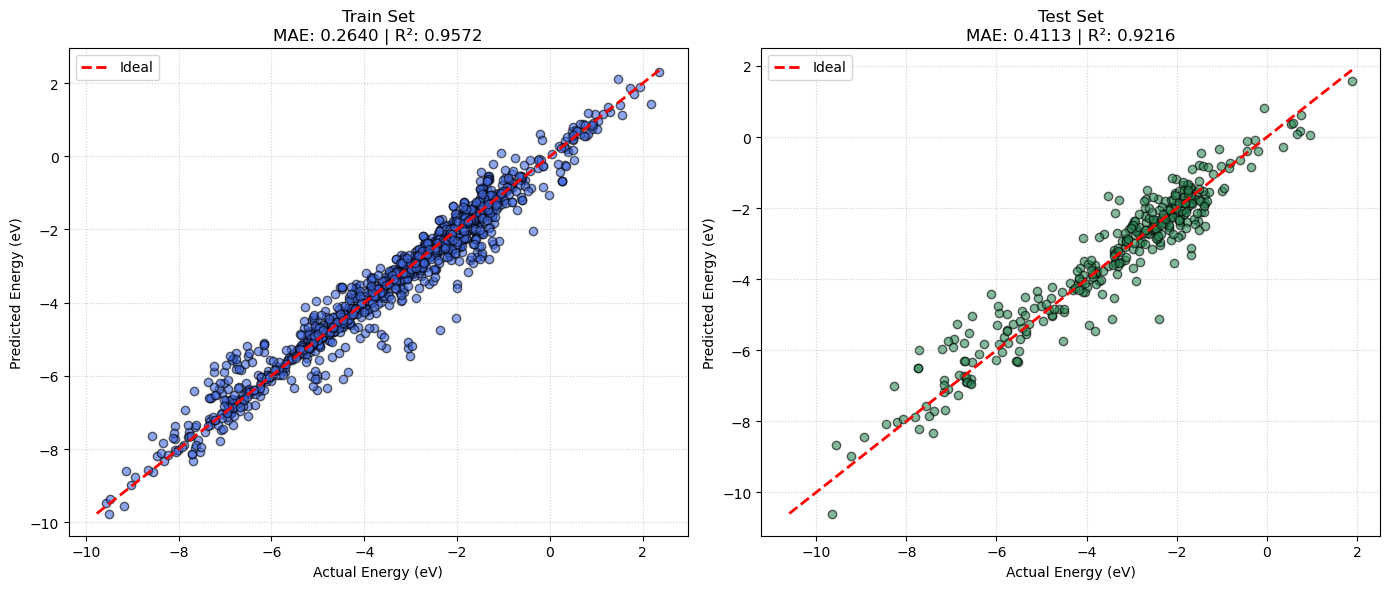


Training Complete. Final Test MAE: 0.4113 eV


In [15]:
import torch
import matplotlib.pyplot as plt

# --- 1. Configuration & Parameter Loading ---
# This pulls directly from your previous tuning cell results
if 'best_params' in locals():
    best_feature_dim = best_params['feature_dim']
    best_hidden_dim = best_params['hidden_dim']
    best_num_layers = best_params['num_layers']
    best_lr = best_params['lr']
    print(f"Using best params: {best_params}")
else:
    # Fallback defaults if tuning wasn't run
    best_feature_dim, best_hidden_dim, best_num_layers, best_lr = 16, 64, 2, 0.01
    print("Warning: best_params not found. Using manual defaults.")

# --- 2. Initialize Model & Tools ---
model = GNNModel(
    feature_dim=best_feature_dim, 
    hidden_dim=best_hidden_dim, 
    output_dim=1, 
    num_layers=best_num_layers
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=best_lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
loss_fn = torch.nn.MSELoss()

# --- 3. Training with Early Stopping ---
num_epochs = 450
patience = 15  # Allow more patience for the final training
best_val_mae = float('inf')
best_state = None
counter = 0

print(f'\nStarting final training (Max {num_epochs} epochs)...')

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for graph in train_graphs:
        optimizer.zero_grad()
        pred = model(graph)
        loss = loss_fn(pred, graph.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_graphs)
    
    # Validation step to check for overfitting
    model.eval()
    val_targets = [g.y.item() for g in val_graphs]
    val_mae, _, _, _, _, _ = evaluate_model(model, val_graphs, val_targets)
    
    # Learning rate adjustment
    scheduler.step(val_mae)
    
    # Early Stopping Logic
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        best_state = model.state_dict()
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Stopping early at epoch {epoch+1}. Restoring best weights.")
            model.load_state_dict(best_state)
            break
            
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:03d} | Train Loss: {avg_loss:.4f} | Val MAE: {val_mae:.4f}")

# --- 4. Final Evaluation & Parity Plots ---
print("\n--- Final Evaluation ---")
# Safely extract targets directly from graphs
train_targets = [g.y.item() for g in train_graphs]
test_targets = [g.y.item() for g in test_graphs]

train_metrics = evaluate_model(model, train_graphs, train_targets)
test_metrics = evaluate_model(model, test_graphs, test_targets)

# Unpack results
train_mae, train_rmse, train_r2, train_max, train_preds, train_actuals = train_metrics
test_mae, test_rmse, test_r2, test_max, test_preds, test_actuals = test_metrics

# --- 5. Visualization ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plotting function to keep it clean
def plot_parity(ax, actual, pred, mae, r2, title, color):
    ax.scatter(actual, pred, alpha=0.6, color=color, edgecolors='k')
    lims = [min(min(actual), min(pred)), max(max(actual), max(pred))]
    ax.plot(lims, lims, 'r--', lw=2, label='Ideal')
    ax.set_xlabel('Actual Energy (eV)')
    ax.set_ylabel('Predicted Energy (eV)')
    ax.set_title(f'{title}\nMAE: {mae:.4f} | R²: {r2:.4f}')
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.6)

plot_parity(ax1, train_actuals, train_preds, train_mae, train_r2, "Train Set", "royalblue")
plot_parity(ax2, test_actuals, test_preds, test_mae, test_r2, "Test Set", "seagreen")



plt.tight_layout()
plt.show()

print(f"\nTraining Complete. Final Test MAE: {test_mae:.4f} eV")